# California House Price Prediction

**Objective:** Predict the median house value for California districts using demographic and geographic
features from the 1990 census, and compare several regression models to find the best-performing one.

**Dataset:** [California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices) — 20,640 rows, 10 columns (9 features + target).

**Workflow:**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Preprocessing pipeline (imputation, scaling, encoding)
5. Baseline model
6. Model selection via cross-validation (Linear/Ridge/Lasso, Random Forest, HistGradientBoosting, XGBoost)
7. Hyperparameter tuning (GridSearchCV)
8. Final evaluation & residual analysis
9. Feature importance
10. Save the trained pipeline for deployment

**Stack:** pandas, NumPy, scikit-learn, XGBoost, matplotlib, seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [2]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "housing.csv"          # update path for a different dataset
TARGET_COL = "median_house_value" # target column name
MODEL_OUT_PATH = "house_price_model.joblib"

## 1. Load Data

In [3]:
df = pd.read_csv(CSV_PATH)

In [4]:
print("Dataframe shape:", df.shape)

Dataframe shape: (20640, 10)


In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


## 2. Exploratory Data Analysis (EDA)

In [6]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

**Column details:**

1. `longitude` — how far west a district is; higher = farther west
2. `latitude` — how far north a district is; higher = farther north
3. `housing_median_age` — median age of a house within a block; lower = newer
4. `total_rooms` — total number of rooms within a block
5. `total_bedrooms` — total number of bedrooms within a block
6. `population` — total number of people residing within a block
7. `households` — total number of households (groups of people residing in a home unit) for a block
8. `median_income` — median income for households within a block (tens of thousands of USD)
9. `median_house_value` — **target**: median house value for households within a block (USD)
10. `ocean_proximity` — location of the block relative to the ocean/sea

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
num_cols = df.select_dtypes(include=['float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [9]:
# missing value analysis
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [10]:
# duplicate rows
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


In [11]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


## 3. Data Visualization

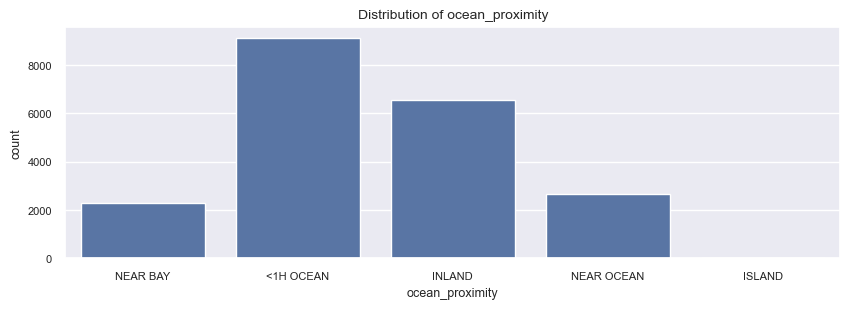

In [12]:
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [13]:
for col in cat_cols:
    print(df[col].value_counts())
    print()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64



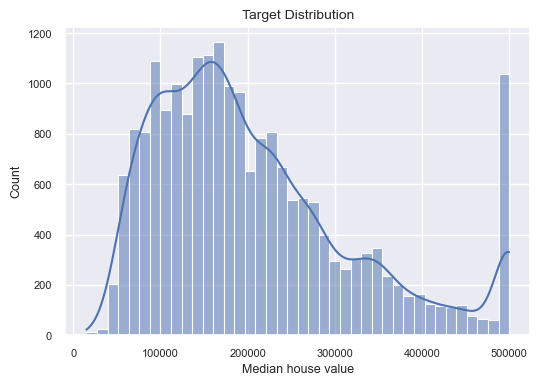

count    20640.000
mean    206855.817
std     115395.616
min      14999.000
25%     119600.000
50%     179700.000
75%     264725.000
max     500001.000
Name: median_house_value, dtype: float64

In [14]:
# target distribution
plt.figure(figsize=(6, 4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target Distribution")
plt.xlabel("Median house value")
plt.show()

df[TARGET_COL].describe()

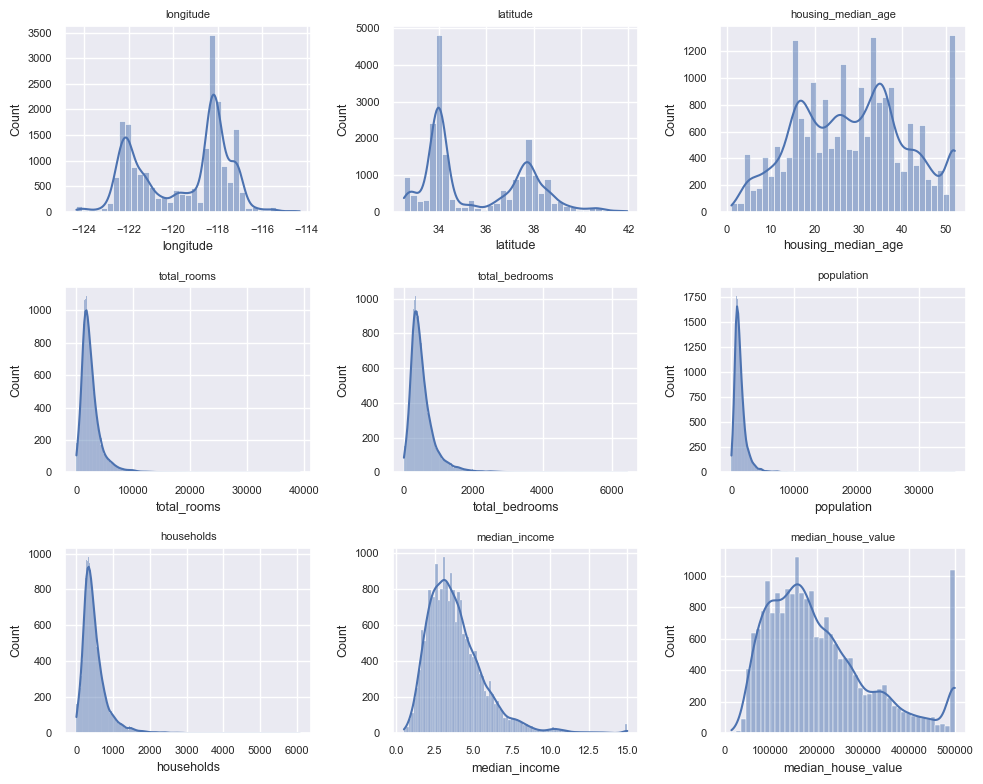

In [15]:
# histogram plot - distribution of all numeric features
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

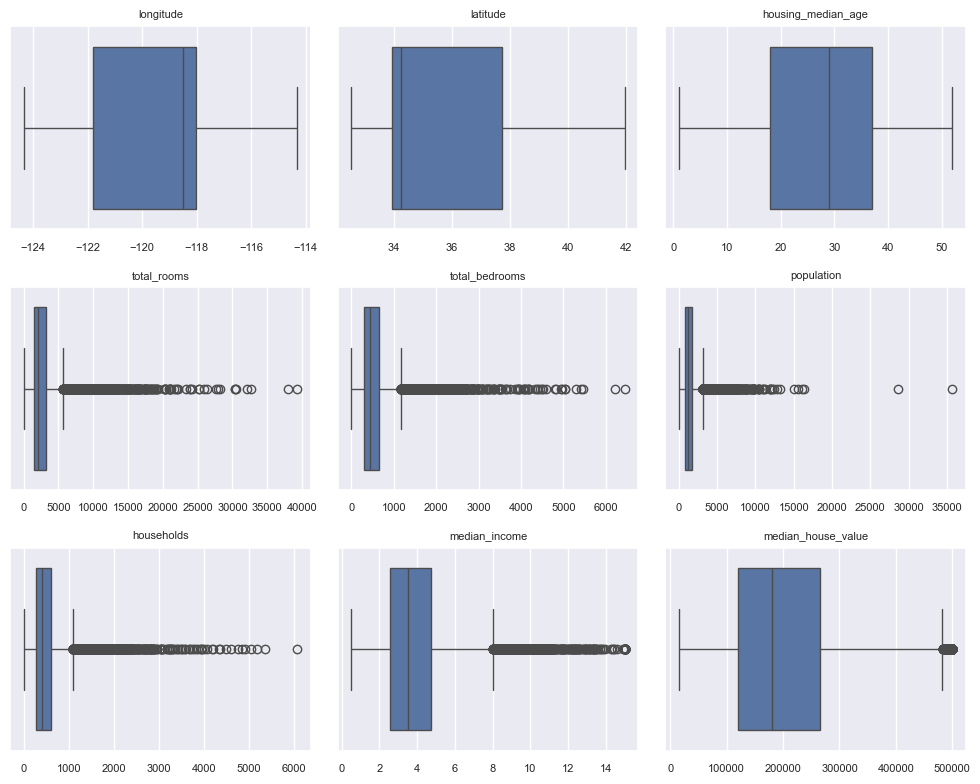

In [16]:
# outlier analysis
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

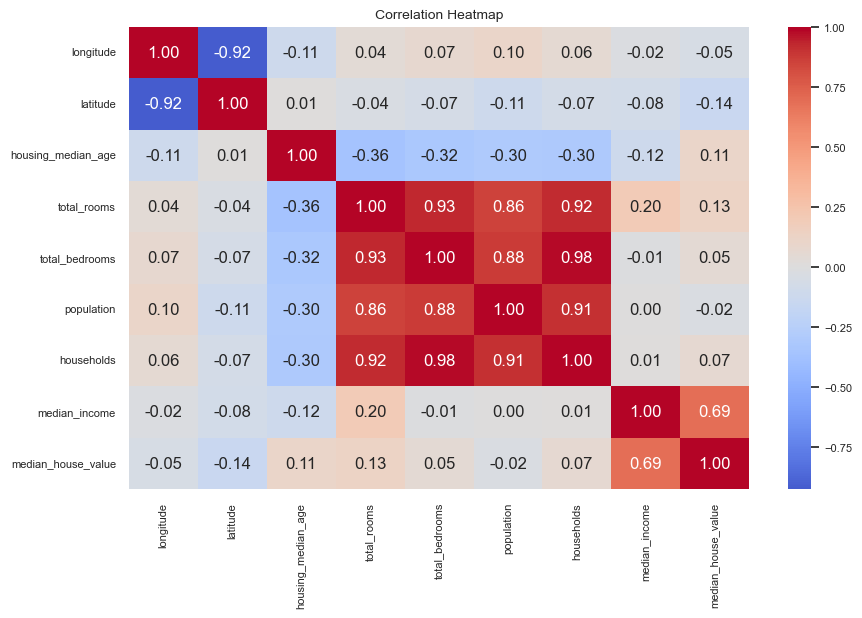

In [17]:
# correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("Correlation with target:")
print(corr_with_target)

Correlation with target:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


## 4. Feature Engineering

Raw counts like `total_rooms` or `total_bedrooms` are more informative as **ratios**
(per household / per room) than as absolute block totals. Adding these engineered
features is a standard, well-documented improvement for this dataset and typically
improves model performance over the raw counts alone.

In [19]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

new_features = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
rooms_per_household,20640.000,5.429,2.474,0.846,4.441,5.229,6.052,141.909
bedrooms_per_room,20433.000,0.213,0.058,0.100,0.175,0.203,0.240,1.000
population_per_household,20640.000,3.071,10.386,0.692,2.430,2.818,3.282,1243.333


In [20]:
# how well do the new features correlate with the target?
df[new_features + [TARGET_COL]].corr()[TARGET_COL].sort_values(ascending=False)

median_house_value          1.000
rooms_per_household         0.152
population_per_household   -0.024
bedrooms_per_room          -0.256
Name: median_house_value, dtype: float64

## 5. Data Preprocessing

In [21]:
# separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [22]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY,6.984,0.147,2.556
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY,6.238,0.156,2.110
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY,8.288,0.130,2.802
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY,5.817,0.184,2.548
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY,6.282,0.172,2.181


In [23]:
y.head()

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

In [24]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("train shape:", X_train.shape)
print("test shape :", X_test.shape)

train shape: (16512, 12)
test shape : (4128, 12)


### Preprocessing pipeline

In [25]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numerical features  :", numerical_features)
print("Categorical features:", categorical_features)

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features  : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Categorical features: ['ocean_proximity']


## 6. Baseline Model

In [26]:
def evaluate(y_true, y_pred, label=""):
    """Compute and print RMSE, MAE and R2 for a set of predictions."""
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE : {mae:,.2f}")
    print(f"R2  : {r2:.4f}\n")
    return {"rmse": rmse, "mae": mae, "r2": r2}

In [27]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

baseline_pipe.fit(X_train, y_train)

train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

_ = evaluate(y_train, train_baseline_pred, "Baseline (Linear Regression) - Train")
_ = evaluate(y_test, test_baseline_pred, "Baseline (Linear Regression) - Test")

--- Baseline (Linear Regression) - Train ---
RMSE: 67,593.21
MAE : 48,785.16
R2  : 0.6582

--- Baseline (Linear Regression) - Test ---
RMSE: 69,127.04
MAE : 49,645.49
R2  : 0.6353



## 7. Model Selection (Cross-Validation)

In [28]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=5000),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "HistGB": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
}

In [29]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [30]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })

cv_results = pd.DataFrame(rows).sort_values("cv_rmse").reset_index(drop=True)
print("=== CV Model Comparison ===")
cv_results

=== CV Model Comparison ===


,model,cv_rmse,cv_mae,cv_r2
0,HistGB,46910.062,31201.648,0.835
1,XGBoost,47224.151,31122.001,0.833
2,RandomForest,50299.453,32911.449,0.811
3,Ridge,67849.203,48876.806,0.655
4,Lasso,67857.420,48879.766,0.655
5,LinearRegression,67858.779,48879.909,0.655


C:\Users\rjaga\AppData\Local\Temp\ipykernel_11144\783222298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cv_results, x="cv_rmse", y="model", palette="viridis")


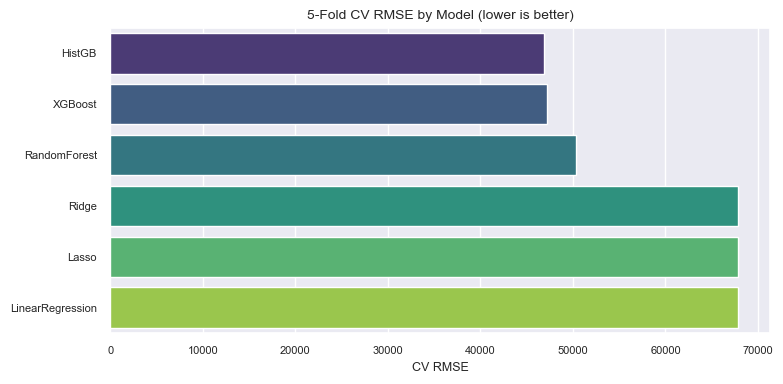

In [31]:
# visualize model comparison
plt.figure(figsize=(8, 4))
sns.barplot(data=cv_results, x="cv_rmse", y="model", palette="viridis")
plt.title("5-Fold CV RMSE by Model (lower is better)")
plt.xlabel("CV RMSE")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [32]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]
best_model_name = best_row["model"]

print("Best model based on CV RMSE:")
print(best_row)

Best model based on CV RMSE:
model        HistGB
cv_rmse   46910.062
cv_mae    31201.648
cv_r2         0.835
Name: 0, dtype: object


**Best model: HistGradientBoostingRegressor** — lowest CV RMSE and strong R2 among all candidates.

## 8. Hyperparameter Tuning (HistGradientBoosting)

We search over the parameter space with `RandomizedSearchCV` rather than an exhaustive grid — it
covers the same space with far fewer fits, which matters once the grid has hundreds of combinations.

In [33]:
hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [34]:
# hyperparameter grid
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "model__max_depth": [None, 3, 6, 10],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 0.5, 1.0]
}

In [35]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

# perform grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 1024 candidates, totalling 5120 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [None, 3, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [36]:
print("=== TUNED HistGB (CV) ===")
print("Best CV RMSE:", -grid.best_score_)
print("Best params :", grid.best_params_)

=== TUNED HistGB (CV) ===
Best CV RMSE: 46190.17950405139
Best params : {'model__l2_regularization': 0.1, 'model__learning_rate': 0.15, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


## 9. Retraining With Best Params

We rebuild the final pipeline directly from `grid.best_params_` (rather than re-typing values by hand)
so the final model always matches whatever the search actually found.

In [37]:
best_params = {k.replace("model__", ""): v for k, v in grid.best_params_.items()}

hgb_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE, **best_params))
    ]
)

hgb_best.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 10. Final Evaluation

In [38]:
train_final_pred = hgb_best.predict(X_train)
test_final_pred = hgb_best.predict(X_test)

train_metrics = evaluate(y_train, train_final_pred, "Final Model (Tuned HGB) - Train")
test_metrics = evaluate(y_test, test_final_pred, "Final Model (Tuned HGB) - Test")

--- Final Model (Tuned HGB) - Train ---
RMSE: 30,807.54
MAE : 20,933.16
R2  : 0.9290

--- Final Model (Tuned HGB) - Test ---
RMSE: 44,802.57
MAE : 29,531.03
R2  : 0.8468



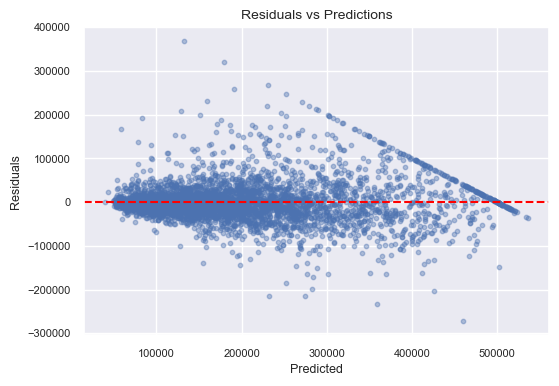

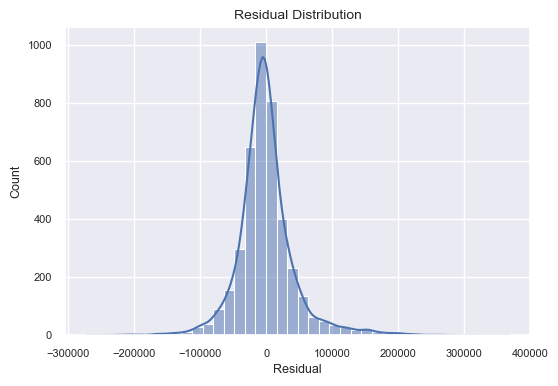

In [39]:
# residual plots
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

## 11. Feature Importance

`HistGradientBoostingRegressor` has no built-in `feature_importances_`, so we use
**permutation importance** on the test set to see which features drive predictions most.

In [40]:
perm_result = permutation_importance(
    hgb_best, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df

,feature,importance_mean,importance_std
1,latitude,0.464,0.012
0,longitude,0.450,0.008
7,median_income,0.381,0.012
11,population_per_household,0.146,0.005
8,ocean_proximity,0.129,0.006
2,housing_median_age,0.049,0.003
9,rooms_per_household,0.042,0.003
10,bedrooms_per_room,0.018,0.002
3,total_rooms,0.004,0.001
4,total_bedrooms,0.002,0.001


C:\Users\rjaga\AppData\Local\Temp\ipykernel_11144\2810464881.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance_mean", y="feature", palette="magma")


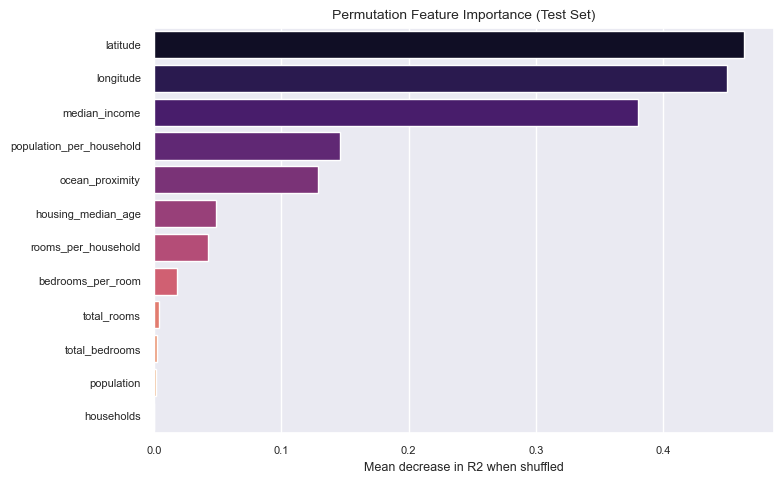

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance_mean", y="feature", palette="magma")
plt.title("Permutation Feature Importance (Test Set)")
plt.xlabel("Mean decrease in R2 when shuffled")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 12. Save the Trained Pipeline

Persisting the full pipeline (preprocessing + model) means a new raw record can be scored directly,
without re-implementing the preprocessing logic separately — useful for wrapping the model in an API.

In [42]:
joblib.dump(hgb_best, MODEL_OUT_PATH)
print(f"Saved trained pipeline to: {MODEL_OUT_PATH}")

# quick sanity check: reload and predict on one row
reloaded = joblib.load(MODEL_OUT_PATH)
sample = X_test.iloc[[0]]
print("Reloaded model prediction:", reloaded.predict(sample)[0])
print("Actual value            :", y_test.iloc[0])

Saved trained pipeline to: house_price_model.joblib
Reloaded model prediction: 60717.84314404136
Actual value            : 47700.0


## Conclusion

- A tuned **HistGradientBoostingRegressor** outperformed Linear/Ridge/Lasso regression and Random
  Forest / XGBoost baselines on 5-fold cross-validation RMSE.
- Adding engineered ratio features (`rooms_per_household`, `bedrooms_per_room`,
  `population_per_household`) gave the model more directly predictive signal than the raw block-level
  counts alone.
- `median_income` is consistently the strongest single predictor of `median_house_value`, both by
  correlation and by permutation importance — consistent with domain expectations.
- Residuals are roughly centered around zero with some heavier spread at higher price points,
  suggesting the model is more confident on mid-range home values than on the highest-value districts.

**Possible next steps:** try target transformation (log) for the right-skewed target, geospatial
clustering on `latitude`/`longitude`, or stacking the top-performing models.